In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap



---

### **1. Explain how SVM works.**  
**Answer**:  
SVM finds the optimal hyperplane that maximizes the margin between classes. It identifies **support vectors** (data points closest to the hyperplane) to define the decision boundary. For non-linear data, SVM uses **kernel functions** (e.g., RBF, polynomial) to map data into higher dimensions where separation is possible. Regularization parameter **C** balances margin width and classification error.

---

### **2. What are kernels in SVM, and why are they important?**  
**Answer**:  
Kernels transform input data into higher-dimensional spaces to enable linear separation. Examples include:  
- **Linear**: No transformation.  
- **RBF (Gaussian)**: Handles complex, non-linear boundaries.  
- **Polynomial**: Captures interactions between features.  
The **kernel trick** avoids explicit computation of high-dimensional transformations, making SVM computationally efficient.

---

### **3. How does SVM handle non-linearly separable data?**  
**Answer**:  
By using kernel functions (e.g., RBF, polynomial) to map data into a space where a linear hyperplane can separate classes. Soft-margin SVM (via parameter **C**) allows some misclassifications to generalize better on noisy data.

---

### **4. What is the role of the regularization parameter C in SVM?**  
**Answer**:  
- **High C**: Prioritizes minimizing misclassifications (narrow margin, risk of overfitting).  
- **Low C**: Prioritizes maximizing margin (wider margin, tolerates misclassifications, better generalization).  
It controls the trade-off between margin width and classification accuracy.

---

### **5. Why use SVM over other classifiers (e.g., logistic regression)?**  
**Answer**:  
- Effective in **high-dimensional spaces** (e.g., text/image data).  
- Robust to overfitting via margin maximization.  
- Flexible with kernel functions for non-linear problems.  
- Works well with small datasets and clear class separation.  

---



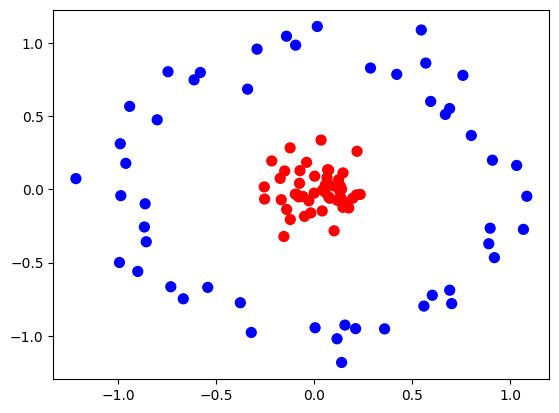

In [ ]:
# Instead of importing from sklearn.datasets.samples_generator, import from sklearn.datasets
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20)

In [ ]:
classifier = SVC(kernel = 'linear')
classifier.fit(X_train,y_train.ravel())
y_pred = classifier.predict(X_test)

In [ ]:
from sklearn.metrics  import accuracy_score
accuracy_score(y_test,y_pred)

0.55

In [8]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

<ipython-input-8-50c9684d90d2>:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


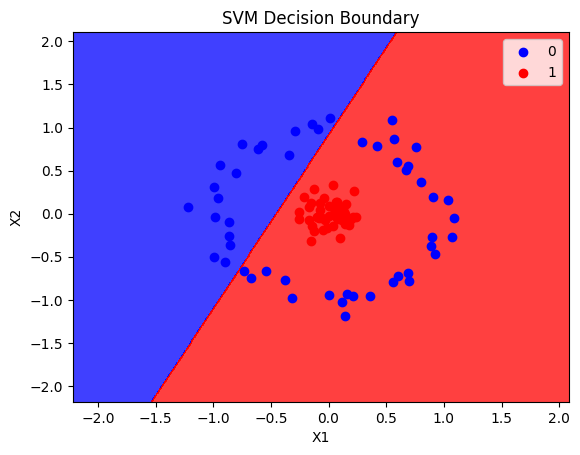

In [9]:
plot_decision_boundary(X,y,classifier)

In [11]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

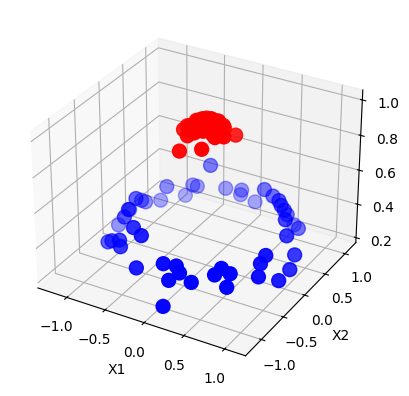

In [12]:
plot_3d_plot(X,y)


In [13]:
rbf_classifier = SVC(kernel='rbf')
rbf_classifier.fit(X_train,y_train)
y_pred = rbf_classifier.predict(X_test)

In [13]:
accuracy_score(y_test, y_pred)


<ipython-input-8-50c9684d90d2>:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


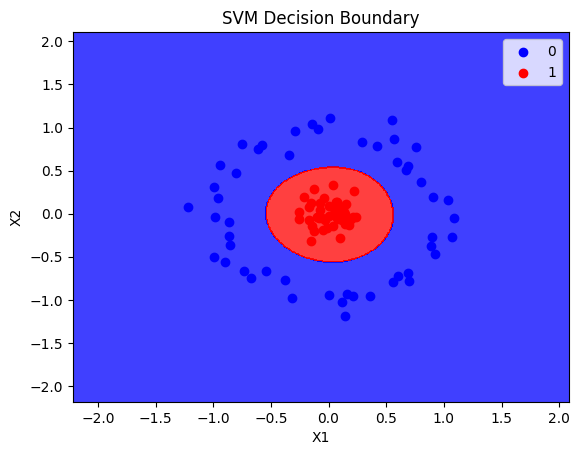

In [14]:
plot_decision_boundary(X, y, rbf_classifier)


In [15]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [16]:
accuracy_score(y_test, y_pred)


1.0

<ipython-input-8-50c9684d90d2>:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


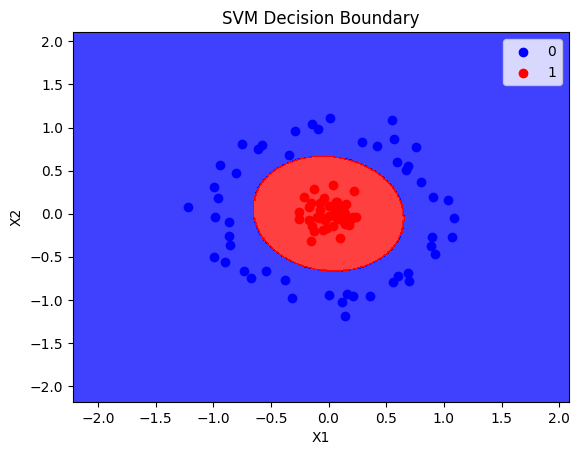

In [17]:
plot_decision_boundary(X, y, poly_classifier)


In [18]:
X

array([[ 7.37971052e-02, -5.18838165e-02],
       [ 1.18300472e-01, -7.46345107e-02],
       [-6.68325217e-01, -7.47389839e-01],
       [ 4.21125041e-01,  7.85603340e-01],
       [-1.50934909e-01,  1.25606782e-01],
       [ 8.91029179e-01, -3.71267340e-01],
       [ 1.24452756e-01,  6.59067200e-02],
       [ 1.20983064e-01,  1.50125265e-02],
       [-1.22101932e-01, -2.05860411e-01],
       [ 1.96752796e-01, -6.06992192e-02],
       [-3.21218188e-01, -9.77343179e-01],
       [-8.66793645e-01, -2.56818483e-01],
       [-1.73565196e-01,  7.50987811e-02],
       [ 4.28642728e-02, -4.04344345e-03],
       [-1.68154773e-01, -7.05607917e-02],
       [-7.27042705e-02,  1.27912951e-01],
       [-3.89320402e-02,  1.84779975e-01],
       [-7.49891308e-02,  4.14187203e-02],
       [ 6.53168746e-02,  7.99811683e-02],
       [-7.93082115e-02, -5.16808101e-02],
       [-6.13278447e-01,  7.48069454e-01],
       [-8.95819803e-02, -3.48113523e-02],
       [ 5.46460769e-01,  1.08884189e+00],
       [ 7.

In [19]:
X_new=np.exp(-(X**2))


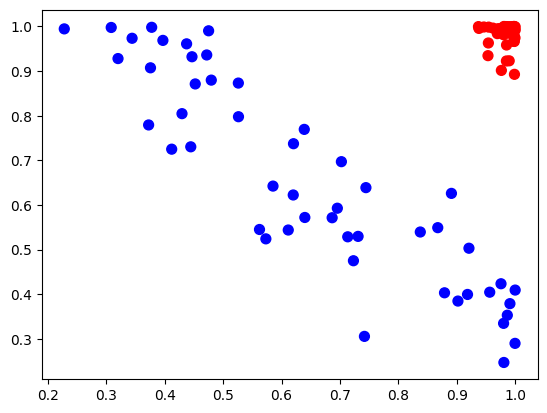

In [20]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')



### Summary:
The code demonstrates the use of Support Vector Machines (SVM) for classification on a synthetic dataset generated using the `make_circles` function. It includes data visualization using 2D and 3D plots, and evaluates the performance of different SVM kernels (linear, radial basis function (RBF), and polynomial) on the dataset.

### Key Points:

1. **Imports**:
   - Libraries used include `numpy`, `pandas`, `matplotlib`, and `sklearn` for data manipulation, visualization, and machine learning.

2. **Data Generation**:
   - A synthetic dataset is created using `make_circles`, which generates a two-dimensional dataset with circular patterns.

3. **Data Visualization**:
   - The dataset is visualized using a scatter plot, where points are colored based on their class labels.

4. **Data Splitting**:
   - The dataset is split into training and testing sets using `train_test_split`, with 20% of the data reserved for testing.

5. **SVM Classifier**:
   - A linear SVM classifier is trained on the training data, and predictions are made on the test set.
   - The accuracy of the linear SVM is calculated, resulting in an accuracy score of 0.55.

6. **Decision Boundary Plotting**:
   - A function `plot_decision_boundary` is defined to visualize the decision boundary of the classifier on the dataset.

7. **3D Plotting**:
   - A 3D scatter plot is created to visualize the data points in three dimensions, where the third dimension is derived from the exponential function of the input features.

8. **Kernel Variants**:
   - The code trains SVM classifiers using different kernels:
     - **RBF Kernel**: Achieves an accuracy of 1.0 on the test set.
     - **Polynomial Kernel**: Also achieves an accuracy of 1.0 on the test set.
   - Warnings are issued regarding the default value of the `gamma` parameter in SVM, indicating that it will change in future versions of `sklearn`.

9. **Error Messages**:
   - There are warnings related to the `c` argument in the plotting functions, suggesting that a 2-D array should be used for consistent color mapping.

10. **Final Visualization**:
    - The final scatter plot visualizes the transformed features using the exponential function, colored by class labels.



### **Support Vector Machines (SVM): Core Concepts and Intuition**

Support Vector Machines (SVMs) are powerful supervised learning algorithms used for classification and regression tasks. The core idea behind SVM is to **find the optimal hyperplane** that separates data points of different classes in a high-dimensional feature space. Here's a breakdown of the key concepts and intuition:

---

#### **1. What is a Hyperplane?**
- A **hyperplane** is a decision boundary that separates data points into classes.
  - In 2D: A line (e.g., $ ax + by + c = 0 $).
  - In 3D: A plane.
  - In n-dimensional space: A subspace of dimension $ n-1 $.
- The goal of SVM is to find the hyperplane that **maximizes the margin** (the distance between the hyperplane and the nearest data points of each class).

---

#### **2. Margin Maximization: The Core Intuition**
- SVM aims to create the "widest street" (margin) between classes to improve generalization.
  - **Support Vectors**: The data points closest to the hyperplane (on the edge of the margin). These determine the position and orientation of the hyperplane.
  - **Hard Margin**: All data points are correctly classified (no misclassifications). Only works for linearly separable data.
  - **Soft Margin**: Allows some misclassifications to handle noisy or overlapping data. Controlled by the regularization parameter $ C $:
    - **Small $ C $**: Prioritize a wider margin, allowing more misclassifications.
    - **Large $ C $**: Prioritize fewer misclassifications, resulting in a narrower margin.

---

#### **3. Kernel Trick: Handling Non-Linear Data**
- **Problem**: Real-world data is rarely linearly separable.
- **Solution**: Use a **kernel function** to map input data into a higher-dimensional space where a linear separation is possible.
  - **Common Kernels**:
    1. **Linear**: $ K(x, y) = x^T y $ (no transformation).
    2. **Polynomial**: $ K(x, y) = (x^T y + c)^d $ (maps data to polynomial features).
    3. **RBF (Radial Basis Function)**: $ K(x, y) = \exp(-\gamma \|x - y\|^2) $ (handles infinite-dimensional transformations using Gaussian similarity).
    4. **Sigmoid**: $ K(x, y) = \tanh(\kappa x^T y + c) $.
- **Kernel Trick**: Avoids explicitly computing the transformation (computationally efficient).

---

#### **4. Optimization Problem in SVM**
- **Objective**: Maximize the margin while minimizing classification errors.
- **Primal Formulation** (for linear SVM):
  $$
  \min_{w, b} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i
  $$
  Subject to:
  $$
  y_i (w^T x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0
  $$
  - $ w $: Weight vector perpendicular to the hyperplane.
  - $ b $: Bias term (shifts the hyperplane).
  - $ \xi_i $: Slack variables for soft margin (allow misclassifications).
- **Dual Formulation**: Uses Lagrange multipliers to solve the problem in terms of dot products, enabling the kernel trick.

---

#### **5. Parameters and Their Impact**
- **$ C $ (Regularization Parameter)**:
  - Controls the trade-off between maximizing the margin and minimizing classification errors.
  - High $ C $: Overfitting (hard margin).
  - Low $ C $: Underfitting (wide margin with many misclassifications).
- **$ \gamma $ (Kernel Coefficient)**:
  - Determines the influence of a single training example.
  - High $ \gamma $: Model fits training data closely (risk of overfitting).
  - Low $ \gamma $: Model is smoother (generalizes better).
- **Degree** (for polynomial kernels):
  - Higher degree = more complex decision boundaries.

---

#### **6. Example: Why RBF Kernel Works for Circles**
In your code, the dataset was generated using `make_circles`, which creates concentric circles. This data is **non-linearly separable** in 2D:
- A **linear SVM** fails because no straight line can separate the classes (55% accuracy).
- **RBF or Polynomial Kernels** transform the data into a higher-dimensional space where a linear hyperplane can separate the classes (100% accuracy).

For example, the RBF kernel maps the 2D data into a 3D space using a Gaussian function, creating a clear separation.

---

#### **7. Advantages of SVM**
- Effective in high-dimensional spaces (e.g., images, text).
- Works well with small datasets.
- Robust to overfitting due to margin maximization.
- Flexible via kernel choice.

---

#### **8. Limitations**
- Computationally expensive for large datasets.
- Sensitive to feature scaling (normalize/standardize data).
- Requires careful tuning of $ C $, $ \gamma $, and kernel type.

---

#### **9. Visualizing SVM Intuition**
- **Linearly Separable Data**:
  - Imagine two clusters of points (e.g., red and blue). The SVM finds the line (hyperplane) that splits them with the maximum margin.
- **Non-Linear Data**:
  - Use the kernel trick to "lift" data into higher dimensions where a linear split exists (e.g., transforming circles into a bowl-shaped surface).

---

#### **10. Real-World Analogy**
Think of SVM as a **fencing coach**:
- You want to build a fence between two groups of sheep (red and blue).
- The coach finds the **widest possible gap** between the groups to place the fence (maximize margin).
- If some sheep wander across the fence (noise), the coach adjusts the fence slightly to balance spacing and accuracy (soft margin).
- If the groups are in a circle (non-linear), the coach uses a creative approach (kernel) to split them (e.g., using a circular fence in transformed space).

---

### **Summary**
SVMs are a powerful tool for classification by:
1. Finding the hyperplane with the **maximum margin**.
2. Using **kernels** to handle non-linear data.
3. Balancing margin width and classification errors via **$ C $** and **$ \gamma $**.

.


---

### **1. Problem Setup: Separating Classes**
**Goal**: Find the best boundary (hyperplane) to separate two classes (e.g., apples vs. oranges).

**Illustration**:  
Imagine plotting two classes on a 2D graph.  
```
Apples (Red):   • • •  
Oranges (Blue):   • • •  
```  
You want a line that cleanly separates the two groups.

---

### **2. Hyperplane Selection**
**Step**:  
- SVM identifies all possible lines (hyperplanes) that separate the classes.  
- It picks the one with the **maximum margin** (distance between the hyperplane and the nearest points of each class).  

**Illustration**:  
```
Best Line (Max Margin):  
Red Points (Apples) →  ↑ Margin ↑ ← Blue Points (Oranges)  
```  
**Why?** A wider margin reduces overfitting and improves generalization.

---

### **3. Support Vectors Define the Boundary**
**Step**:  
- The closest points from each class to the hyperplane are called **support vectors**.  
- These points "support" or define the optimal hyperplane.  

**Illustration**:  
```
Support Vectors:  
• (Red Closest to Line)  ←→  • (Blue Closest to Line)  
```  
Only these points matter for defining the decision boundary.

---

### **4. Handling Non-Linear Data with Kernels**
**Problem**: If classes are not linearly separable (e.g., concentric circles).  
```
Non-Separable Data:  
○ (Outer Circle)  
• (Inner Circle)  
```  
**Solution**: Use a **kernel function** to map data to a higher dimension.  

**Example (RBF Kernel)**:  
- Transform 2D data into 3D using a Gaussian function (e.g., $ z = e^{-\gamma(x^2 + y^2)} $).  
- Now, a flat plane can separate the classes in 3D.  

**Illustration**:  
```
3D Transformation:  
••• (Top Bowl)  
○○○ (Bottom Bowl)  
← Plane Separates Them →  
```  
**Kernel Trick**: Avoids explicitly computing the transformation—computes similarity directly in high-D space.

---

### **5. Optimization: Solving the Math**
**Step**:  
SVM solves a **constrained optimization problem** to maximize the margin while minimizing misclassifications.  

**Key Equations**:  
- **Hyperplane**: $ w^T x + b = 0 $ (where $ w $ = weights, $ b $ = bias).  
- **Margin**: $ \frac{2}{\|w\|} $.  
- **Objective**: Minimize $ \|w\|^2 $ (maximize margin) subject to:  
  - $ y_i(w^T x_i + b) \geq 1 $ (correct classification).  

**Soft Margin (C Parameter)**:  
- Allows some points to violate the margin (misclassifications) to avoid overfitting.  
- **High C**: Strictly enforce margin (risk of overfitting).  
- **Low C**: Allow more violations for a wider margin (better generalization).  

---

### **6. Final Model: Making Predictions**
**Step**:  
- Once trained, SVM uses the hyperplane to classify new data points:  
  - If $ w^T x + b > 0 $: Class A.  
  - If $ w^T x + b < 0 $: Class B.  

**Illustration**:  
```
New Point: ?  
→ Plug into hyperplane equation:  
  Result = Positive → Red Class  
  Result = Negative → Blue Class  
```

---

### **Real-World Analogy: Fencing Between Two Groups**
Imagine building a fence between two herds of sheep (red and blue):  
1. You want the **widest possible gap** (max margin).  
2. The sheep closest to the fence are **support vectors**.  
3. If the sheep form a circle (non-linear), you **lift the fence into 3D** (kernel trick) to separate them.  
4. You allow a few sheep to cross the fence (soft margin) to keep the fence practical.

---

### **Summary of Algorithm Steps**
| Step | Description | Key Concept |
|------|-------------|-------------|
| 1 | Plot data in feature space | Input data points |
| 2 | Find all possible hyperplanes separating classes | Linear separability |
| 3 | Choose the hyperplane with maximum margin | Margin maximization |
| 4 | Use support vectors to define the optimal hyperplane | Support vectors |
| 5 | Apply kernel trick for non-linear data | Kernels (RBF, polynomial) |
| 6 | Optimize using soft margin (C parameter) | Regularization |
| 7 | Classify new points using the hyperplane | Decision boundary |

This approach makes SVM robust for both linear and complex non-linear classification tasks! 🚀